# Combine Files

In [1]:
from data_analysis import combine_pipeline_csvs_to_lexical_master, clean_variation_and_subreddit_columns
import pandas as pd

In [ ]:
# combine_pipeline_csvs_to_lexical_master(convokit_root='/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit')

[1/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Age-Variation/subreddit-college_lexical_df.csv
[2/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Age-Variation/subreddit-parent_lexical_df.csv
[3/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Age-Variation/subreddit-teenagers_lexical_df.csv
[4/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Culture-Variation/subreddit-books_lexical_df.csv
[5/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Culture-Variation/subreddit-movies_lexical_df.csv
[6/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Culture-Variation/subreddit-religion_lexical_df.csv
[7/9] Reading /Users/nickvick

PosixPath('/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/lexical_master.csv')

In [2]:
df = pd.read_csv('/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/lexical_master.csv')
print(df.head())

             timestamp utterance_id       speaker_id  \
0  2012-01-01 10:13:05        nylo3   throwaway19234   
1  2012-01-04 17:27:59        o332f     AmpleDeficit   
2  2012-01-03 20:29:10        o1uwt   Sliverfish7654   
3  2012-01-03 19:59:41        o1to7  doesntmatter108   
4  2012-01-04 23:05:24        o3hu3        MyRoomate   

                                            raw_text  \
0  Looking for good grab and go snacks, microwave...   
1  In a nutshell, I'm a community college student...   
2  Does anybody know any grants or scholarships t...   
3  I am just starting classes to get my AAS. I FI...   
4  I'm thinking about becoming a lawyer. I don't ...   

   num_utterances_by_speaker  post_depth  score  num_direct_replies  \
0                          1           0      1                   6   
1                          3           0      6                   4   
2                          1           0      0                   1   
3                          5           0  

In [4]:
df = clean_variation_and_subreddit_columns(df)
print(df.head())

             timestamp utterance_id       speaker_id  \
0  2012-01-01 10:13:05        nylo3   throwaway19234   
1  2012-01-04 17:27:59        o332f     AmpleDeficit   
2  2012-01-03 20:29:10        o1uwt   Sliverfish7654   
3  2012-01-03 19:59:41        o1to7  doesntmatter108   
4  2012-01-04 23:05:24        o3hu3        MyRoomate   

                                            raw_text  \
0  Looking for good grab and go snacks, microwave...   
1  In a nutshell, I'm a community college student...   
2  Does anybody know any grants or scholarships t...   
3  I am just starting classes to get my AAS. I FI...   
4  I'm thinking about becoming a lawyer. I don't ...   

   num_utterances_by_speaker  post_depth  score  num_direct_replies  \
0                          1           0      1                   6   
1                          3           0      6                   4   
2                          1           0      0                   1   
3                          5           0  

# Explore Data

/var/folders/dj/6y_wgvgs5m59w08whyk9sjp80000gn/T/ipykernel_94341/1353671203.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = time_df.resample('M').size().rename('post_count')


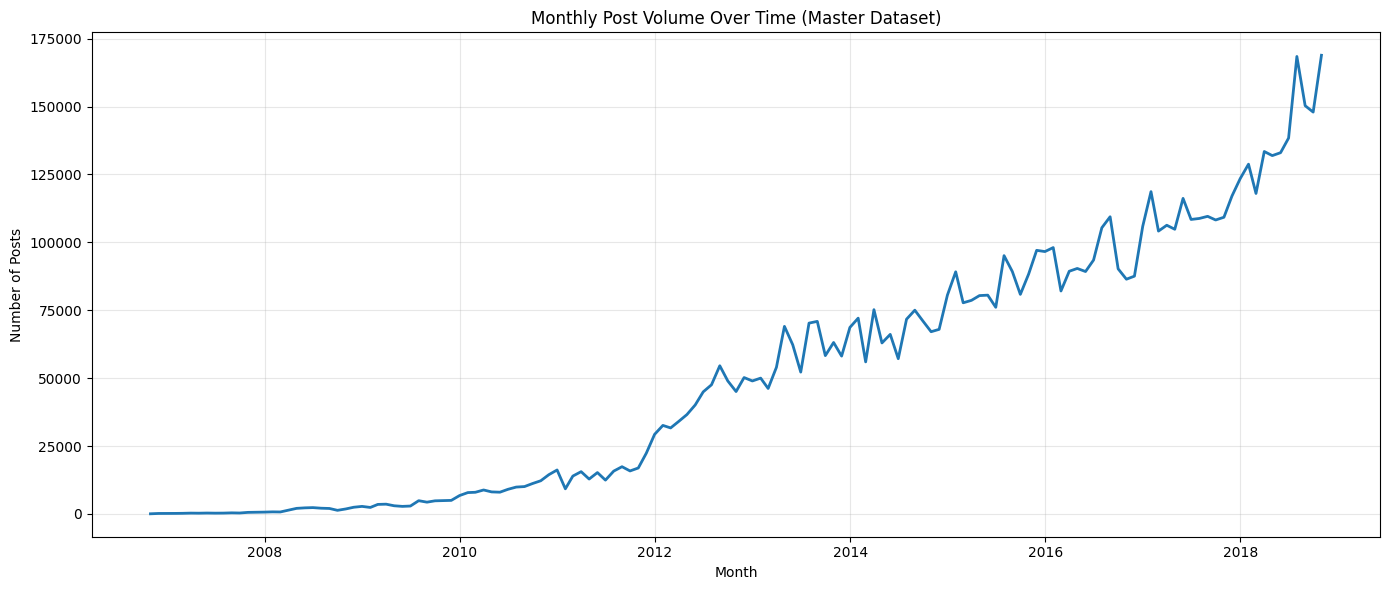

In [12]:
# Monthly Post Volume Over Time
import matplotlib.pyplot as plt

# Support either a timestamp column or a datetime index
if 'timestamp' in df.columns:
    time_df = df.copy()
    time_df['timestamp'] = pd.to_datetime(time_df['timestamp'], errors='coerce')
    time_df = time_df.dropna(subset=['timestamp']).set_index('timestamp')
elif isinstance(df.index, pd.DatetimeIndex):
    time_df = df.copy()
else:
    raise ValueError("df must have a 'timestamp' column or a DatetimeIndex")

monthly_counts = time_df.resample('M').size().rename('post_count')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_counts.index, monthly_counts.values, color='tab:blue', linewidth=2)
ax.set_title('Monthly Post Volume Over Time (Master Dataset)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Posts')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Visualize Temporal Trends

In [5]:
from visualization import *

/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/visualization.py:192: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = ts_df[col].resample(resample_freq).mean()


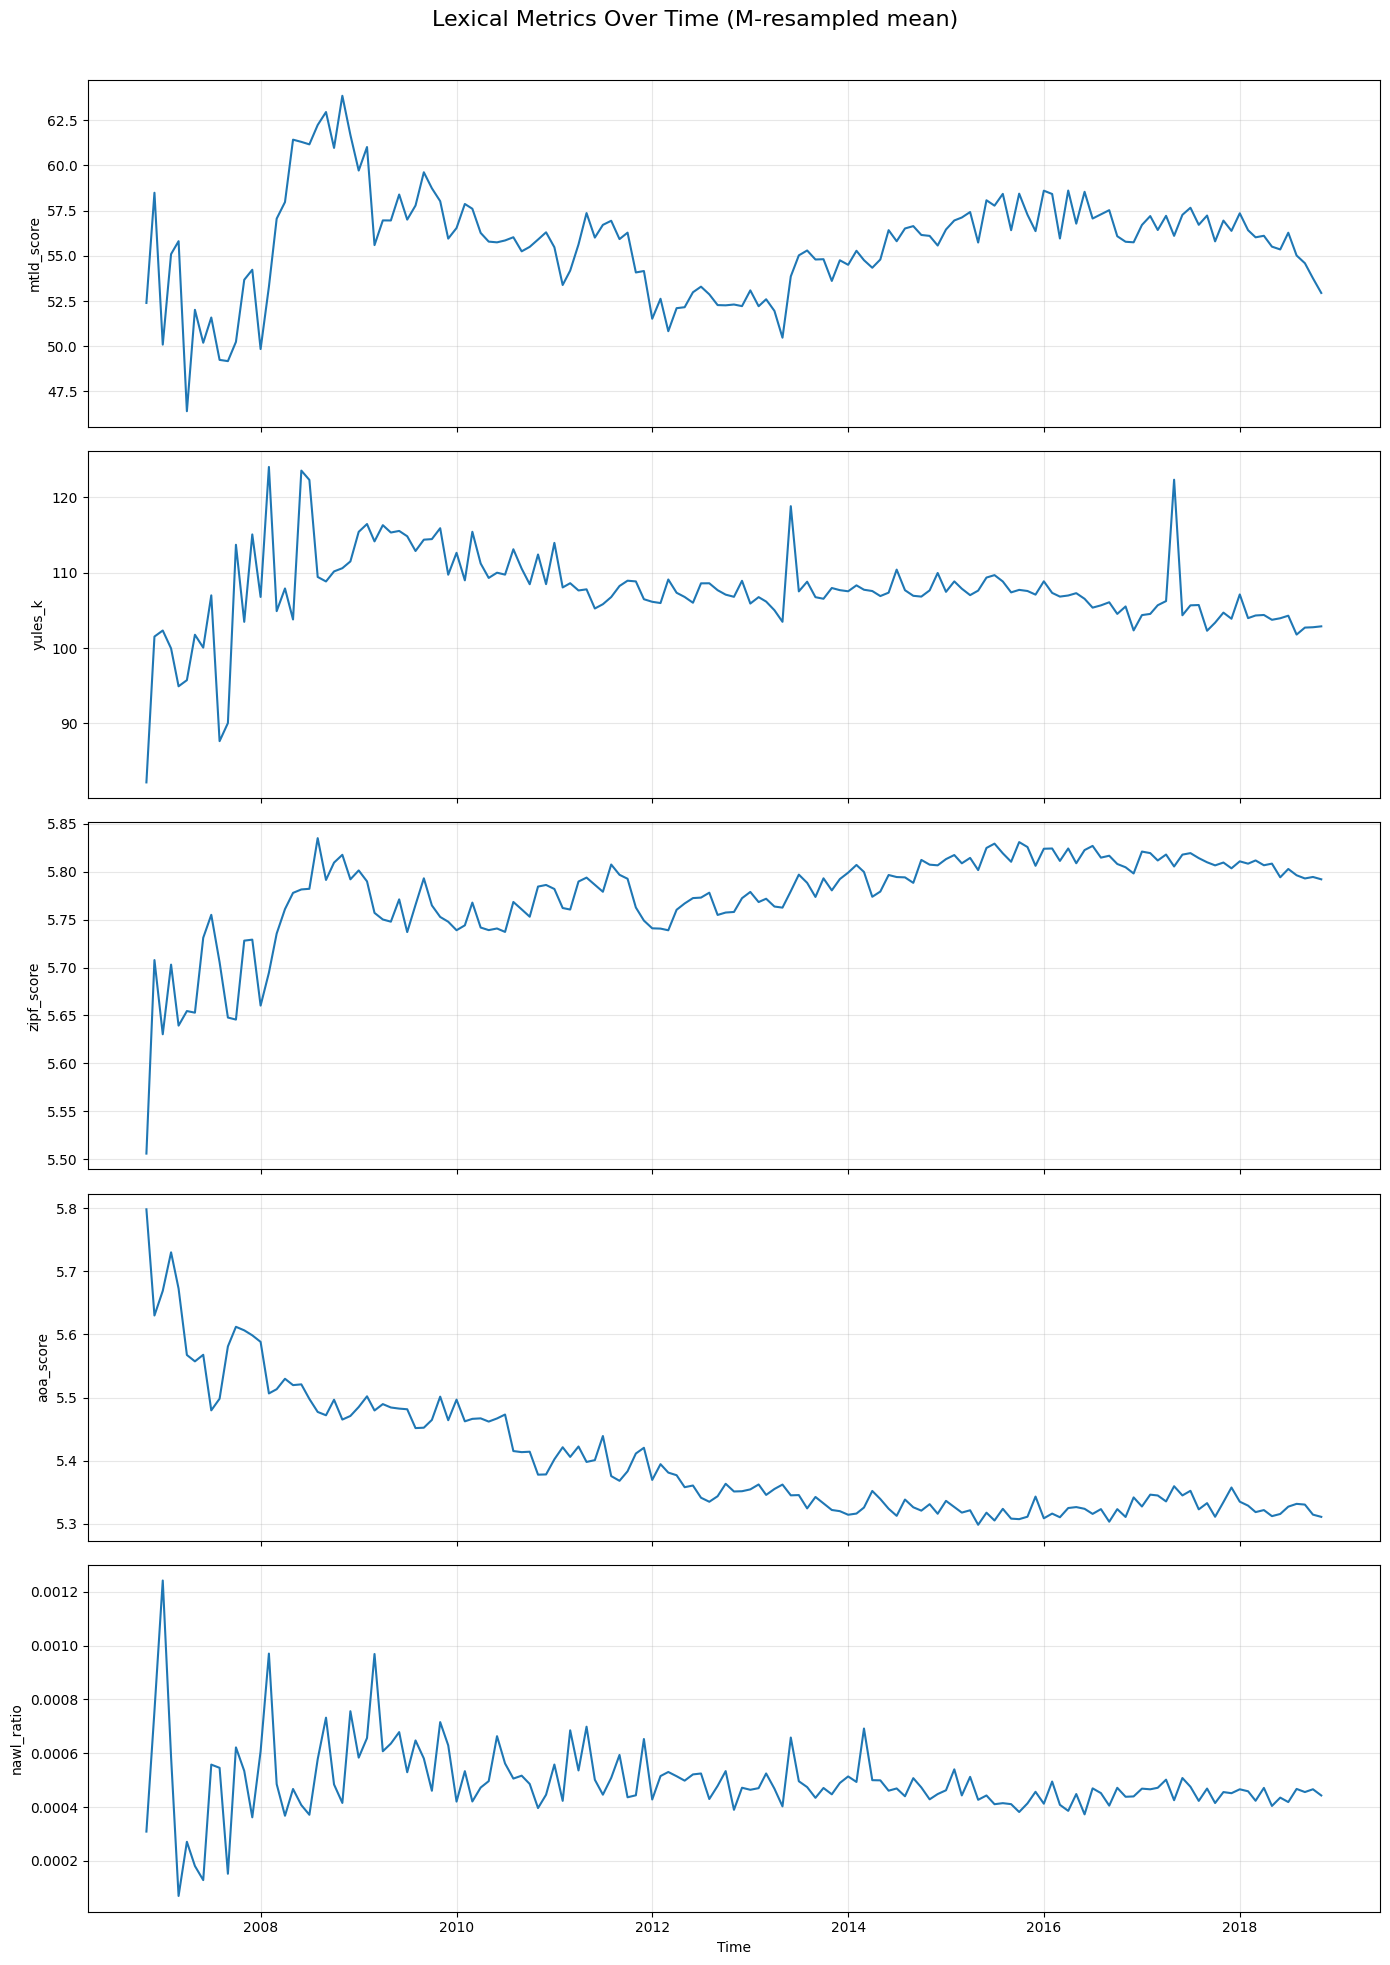

In [7]:
plot_lexical_metrics(df, resample_freq='M')

# Linear Regression

In [13]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Build modeling dataframe
target = 'aoa_score'
features = ['num_utterances_by_speaker', 'post_depth', 'score', 'num_direct_replies', 'subreddit']
model_df = df[[target] + features].copy()

# Numeric cleanup + skew reduction
for c in ['num_utterances_by_speaker', 'post_depth', 'score', 'num_direct_replies']:
    model_df[c] = pd.to_numeric(model_df[c], errors='coerce')

model_df['log_num_utterances'] = np.log1p(model_df['num_utterances_by_speaker'].clip(lower=0))
model_df['log_score'] = np.log1p(model_df['score'].clip(lower=0))
model_df['log_num_direct_replies'] = np.log1p(model_df['num_direct_replies'].clip(lower=0))

X = model_df[['log_num_utterances', 'post_depth', 'log_score', 'log_num_direct_replies', 'subreddit']]
y = model_df[target]

# Keep rows with observed target; feature missingness handled by imputers
y_mask = y.notna()
X = X.loc[y_mask]
y = y.loc[y_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = ['log_num_utterances', 'post_depth', 'log_score', 'log_num_direct_replies']
categorical_features = ['subreddit']

preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ]
)

model = Pipeline([
    ('preprocess', preprocess),
    ('regressor', LinearRegression()),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Train rows: {len(X_train):,}')
print(f'Test rows:  {len(X_test):,}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R^2:  {r2:.4f}')

# Coefficient table
feature_names = model.named_steps['preprocess'].get_feature_names_out()
coefs = model.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index)
print('\nTop 20 coefficients by absolute value:')
print(coef_df.head(20))


Train rows: 5,807,796
Test rows:  1,451,950
RMSE: 0.7427
MAE:  0.4622
R^2:  0.0493

Top 20 coefficients by absolute value:
                         feature  coefficient
8   cat__subreddit_relationships    -0.259394
10        cat__subreddit_science     0.238287
12      cat__subreddit_worldnews     0.196365
7          cat__subreddit_parent    -0.189162
9        cat__subreddit_religion     0.160902
11      cat__subreddit_teenagers    -0.146151
5         cat__subreddit_college     0.060898
6          cat__subreddit_movies    -0.031732
4           cat__subreddit_books    -0.030014
3    num__log_num_direct_replies    -0.025087
0        num__log_num_utterances     0.016547
2                 num__log_score     0.007708
1                num__post_depth     0.000152


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


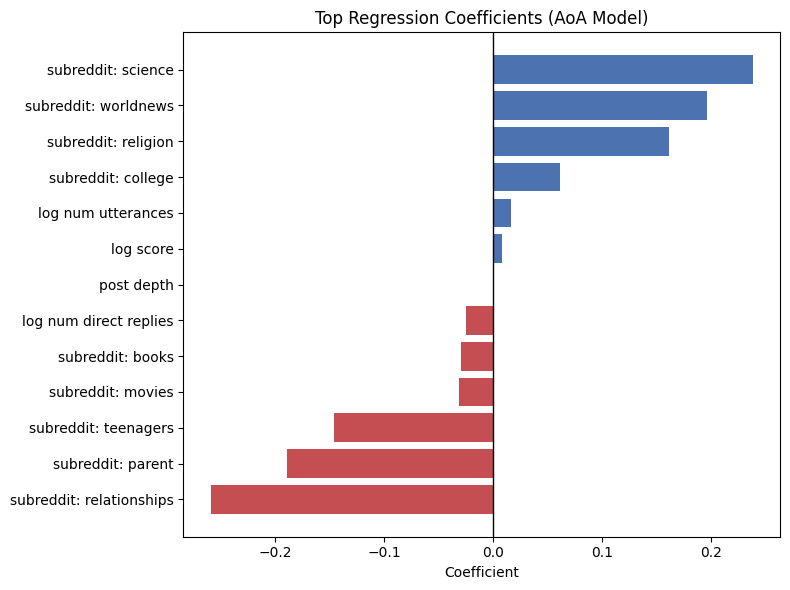

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# coef_df already exists from your notebook: columns = feature, coefficient
plot_df = coef_df.copy()

# clean feature labels
plot_df["label"] = (
    plot_df["feature"]
    .str.replace("cat__subreddit_", "subreddit: ", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top = plot_df.iloc[:20].copy()
top = top.sort_values("coefficient")  # nice horizontal ordering

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c44e52" if v < 0 else "#4c72b0" for v in top["coefficient"]]
ax.barh(top["label"], top["coefficient"], color=colors)
ax.axvline(0, color="black", lw=1)
ax.set_title("Top Regression Coefficients (AoA Model)")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
